<a href="https://colab.research.google.com/github/anniiexp/MAT422/blob/main/1_3_QR_Least_Squares.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MAT422 - Section 1.3 QR Decomposition, Least Squares, and Linear Regression

In [21]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

## Topics:


*   QR Decomposition
*   Least-squares problem

*   Linear Regression







# 1.3.1 QR Decomposition

QR decomposition is a method for factoring a matrix A into two matrices, Q and R such that the equation is $A = QR$.
The matrix Q is has orthonormal columns, meaning its columns are perpendicular to each other and each as a length of 1. The matrix R is upper triangular.
QR decomposition is useful because orthonormal vectors make calculations involving projections and least-square problems simpler and more numerically stable.

In the example below, we use a rectangular full-rank matrix and verify that:

- $Q^TQ = I$, showing that the columns of $Q$ are orthonormal.
- $QR = A$, showing that the decomposition reconstructs the original matrix.

In [22]:
A = np.array([
    [1, 0],
    [1, 1],
    [1, 2],
    [1, 3]
], dtype=float)

# QR decomposition
Q, R = np.linalg.qr(A)

print("Original matrix A:")
print(A)

print("\nMatrix Q:")
print(Q)

print("\nMatrix R:")
print(R)

# check if Q has orthonormal columns
print("\nQ^T Q:")
print(Q.T @ Q)

# check if QR is equal to A
print("\nQ @ R:")
print(Q @ R)

print("\nQ has orthonormal columns:", np.allclose(Q.T @ Q, np.eye(Q.shape[1])))
print("Q @ R reconstructs A:", np.allclose(Q @ R, A))

Original matrix A:
[[1. 0.]
 [1. 1.]
 [1. 2.]
 [1. 3.]]

Matrix Q:
[[-0.5     0.6708]
 [-0.5     0.2236]
 [-0.5    -0.2236]
 [-0.5    -0.6708]]

Matrix R:
[[-2.     -3.    ]
 [ 0.     -2.2361]]

Q^T Q:
[[1. 0.]
 [0. 1.]]

Q @ R:
[[1. 0.]
 [1. 1.]
 [1. 2.]
 [1. 3.]]

Q has orthonormal columns: True
Q @ R reconstructs A: True


The results show the 2 important properties of QR decomposition.
First, $Q^TQ$ is close the identity matrix, so the columns of $Q$ are orthonormal. Second, multiplying $Q$ and $R$ gives back the original matrix $A$.

# 1.3.2 Least-squares problems

A least-squares problem is used when a system of equations has more equations than unknowns, so an exact solution may not exist. Instead, we find a solution $\hat{x}$ that makes the difference between the predicted values and the actual values as small as possible.

The difference is called the **residual**:

$$
r = b - A\hat{x}
$$

The least-squares solution chooses $\hat{x}$ so that the residual norm $\|b - A\hat{x}\|$ is minimized. QR decomposition can also be used to solve least-squares problems efficiently by solving:

$$
R\hat{x} = Q^Tb
$$

This provides a stable way to find the best solution when an exact solution is not possible.

In [23]:
A = np.array([
    [1, 2, -1],
    [2, -1, 3],
    [3, 4, 1],
    [4, 0, 2],
    [5, 3, -2],
    [6, -2, 4]
], dtype=float)

b = np.array([4.2, 3.1, 8.7, 7.5, 9.8, 10.4])

# least squares solution
x_hat, residuals, rank, s = np.linalg.lstsq(A, b, rcond=None)

# residual
residual = b - A @ x_hat

print("Least-squares solution:")
print(x_hat)

print("\nResidual:")
print(residual)

print("\nResidual norm:")
print(np.linalg.norm(residual))

Least-squares solution:
[1.7005 0.8379 0.353 ]

Residual:
[ 1.1768 -0.522  -0.1058 -0.0078 -0.51    0.461 ]

Residual norm:
1.4632747490035587


In [24]:
# same problem with QR decomposition
Q, R = np.linalg.qr(A)

x_qr = np.linalg.solve(R, Q.T @ b)

print("Least-squares solution:", x_hat)
print("QR solution", x_qr)

print("\nSolutions match:")
print(np.allclose(x_hat, x_qr))

Least-squares solution: [1.7005 0.8379 0.353 ]
QR solution [1.7005 0.8379 0.353 ]

Solutions match:
True


In this example, $A$ has 6 rows and 3 columns, meaning there are more equations than unknowns. Because an exact solution may not exist, the least-squares method finds the solution that minimizes the residual norm.

# 1.3.3 Linear Regression

Linear Regression finds the line that best fits a set of data points. It can be written as a least-squares problem using the equation

$$
y = \beta_0 + \beta_1x
$$

where $\beta_0$ is the intercept and $\beta_1$ is the slope.

A design matrix is created with a column of ones for the intercept and a column containing the $x$ values. Least squares is used to find the coefficients that minimize the difference between the actual and predicted values.

In [25]:
# sample data
x = np.array([1, 2, 3, 4, 5, 6, 7, 8], dtype=float)
y = np.array([3.2, 5.1, 6.8, 9.4, 10.7, 13.3, 15.2, 16.9], dtype=float)

# create design matrix
X = np.column_stack([np.ones_like(x), x])

# regression coefficients
beta, _, _, _ = np.linalg.lstsq(X, y, rcond=None)

# predictions
y_pred = X @ beta

# residuals
residuals = y - y_pred

# error measurements
rss = np.sum(residuals**2)
rmse = np.sqrt(np.mean(residuals**2))

print("Intercept:", beta[0])
print("Slope:", beta[1])
print("Predicted values:", y_pred)
print("Residuals:", residuals)
print("Residual Sum of Squares:", rss)
print("RMSE:", rmse)

Intercept: 1.1178571428571438
Slope: 1.9904761904761896
Predicted values: [ 3.1083  5.0988  7.0893  9.0798 11.0702 13.0607 15.0512 17.0417]
Residuals: [ 0.0917  0.0012 -0.2893  0.3202 -0.3702  0.2393  0.1488 -0.1417]
Residual Sum of Squares: 0.4311904761904785
RMSE: 0.23216117143874385


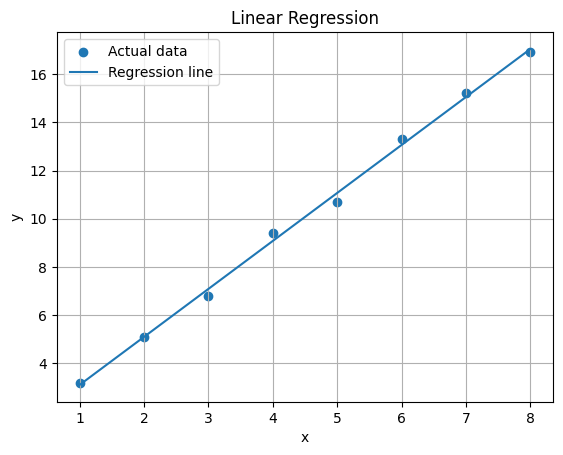

In [26]:
plt.scatter(x, y, label="Actual data")
plt.plot(x, y_pred, label="Regression line")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear Regression")
plt.legend()
plt.grid()

plt.show()

The regression line gives the best-fit line between $x$ and $y$ using least squares.
The slope is approximately 1.99, meaning that for every one-unit increase in $x$, the predicted value of $y$ increases by about 1.99.
The intercept is approximately 1.12, meaning the model predicts $y$ to be about 1.12 when $x = 0$.
The RMSE measures the typical difference between the actual data values and the values predicted by the regression line.

# Reflection



*   QR decomposition: factored matrix $A = QR$, verified that the columns
of Q are orthonormal, and checked that multiplying Q and R reconstructs the original matrix.
*   Least-squares problems: found the best approximate solution to an overdetermined system, calculated the residual and residual norm, and compared the least-squares solution with the solution found using QR decomposition.
*   Linear regression: used least squares to find the best-fit line for a set of data, calculated predictions and residuals, found slope, intercept, and RMSE to understand how well the line fits the data.

